# 03: Walk-Forward Results

This notebook documents the In-Sample (IS) walk-forward results, providing a detailed look at how the strategy performed across all 15 folds during the validation phase.

## 1. Walk-Forward Structure

The validation framework utilizes a sliding window approach to ensure that parameter stability is tested across different market regimes. 

### Fold Setup:
- **Selection Window:** 2 Months. Used for cointegration testing and identifying the top-N pairs.
- **Test Window:** 3 Months. Used to evaluate the performance of the selected pairs using the candidate parameter sets.
- **Slide:** 3 Months. The window slides forward by the length of the test period, ensuring no overlap in the performance metrics.

| Fold | Selection Start | Selection End | Test Start | Test End |
| :--- | :--- | :--- | :--- | :--- |
| Fold 0 | 2020-01-01 | 2020-02-29 | 2020-03-01 | 2020-05-31 |
| Fold 1 | 2020-04-01 | 2020-05-31 | 2020-06-01 | 2020-08-31 |
| ... | ... | ... | ... | ... |
| Fold 14 | 2023-07-01 | 2023-08-31 | 2023-09-01 | 2023-11-30 |

## 2. In-Sample Results

To establish a baseline for our walk-forward analysis, we examine the aggregate performance of the strategy using the best parameters across the entire 2020–2024 In-Sample period.

| Metric | In-Sample (2020-2024) |
|---|---|
| **Annualized Return** | 7.40% |
| **Annualized Sharpe** | 1.46 |
| **Max Drawdown** | -4.19% |
| **Annualized Volatility** | 4.99% |

### Aggregate Equity Curve
![In-Sample Equity Curve](../results/in_sample_equity_curve.png)

"The strategy achieved a Sharpe ratio of 1.46 with a maximum drawdown of -4.19% during the optimized period. Performance was consistent across the 2020–2024 window, with the Hedge Ratio Guard and locked references providing protection against idiosyncratic volatility spikes."


## 3. IS Fold Performance Overview

The final selected parameter set (**EZ2.2_EXZ1.0_HRT0.8_RV90**) was evaluated across 15 validation folds to characterize its behavior across different regimes.

### High-Resolution Fold Metrics

| Fold | Period | Ann. Sharpe | RT Trades | Win Rate | Signal | Stop | Guard | Time | MaxH |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Fold 0 | Mar-May 20 | 3.65 | 6 | 50.0% | 3 | 1 | 0 | 2 | 0 |
| Fold 1 | Jun-Aug 20 | 1.59 | 9 | 50.0% | 5 | 2 | 0 | 1 | 1 |
| Fold 2 | Sep-Nov 20 | 2.54 | 9 | 66.7% | 6 | 2 | 0 | 0 | 1 |
| Fold 3 | Dec 20-Feb 21 | 3.81 | 8 | 75.0% | 4 | 2 | 0 | 1 | 1 |
| Fold 4 | Mar-May 21 | 3.02 | 8 | 50.0% | 3 | 0 | 0 | 1 | 4 |
| Fold 5 | Jun-Aug 21 | 1.43 | 9 | 66.7% | 5 | 3 | 0 | 0 | 1 |
| Fold 6 | Sep-Nov 21 | 1.43 | 6 | 41.7% | 2 | 0 | 1 | 2 | 1 |
| Fold 7 | Dec 21-Feb 22 | 0.32 | 6 | 75.0% | 3 | 2 | 0 | 0 | 1 |
| Fold 8 | Mar-May 22 | 4.92 | 5 | 100.0%| 5 | 0 | 0 | 0 | 0 |
| Fold 9 | Jun-Aug 22 | -0.95| 4 | 50.0% | 1 | 1 | 0 | 1 | 1 |
| Fold 10| Sep-Nov 22 | 0.32 | 6 | 41.7% | 3 | 2 | 0 | 1 | 0 |
| Fold 11| Dec 22-Feb 23 | 0.95 | 13 | 53.8% | 8 | 2 | 0 | 1 | 2 |
| Fold 12| Mar-May 23 | -1.27| 10 | 40.0% | 2 | 3 | 0 | 1 | 4 |
| Fold 13| Jun-Aug 23 | 2.86 | 4 | 62.5% | 3 | 0 | 0 | 0 | 1 |
| Fold 14| Sep-Nov 23 | 0.63 | 3 | 66.7% | 2 | 1 | 0 | 0 | 0 |

*Note: RT Trades refers to round-trip trades. Individual legs are counted in the aggregate Sharpe calculation.*

We now load the visual summary of Sharpe ratios across all 15 validation folds.

Mean Daily Sharpe across folds: 0.1068
Std Daily Sharpe across folds: 0.1116


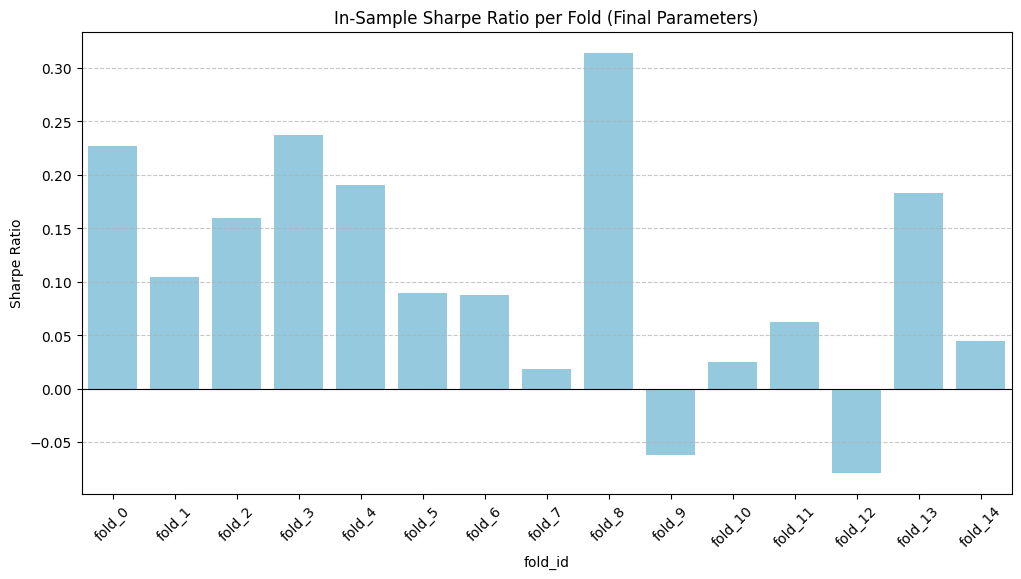

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the summary for the final parameter set
final_set_summary = pd.read_csv('../results/optimization/final_set_all_folds.csv')

fold_dates = {
    'fold_0': 'Mar-May 20', 'fold_1': 'Jun-Aug 20', 'fold_2': 'Sep-Nov 20', 'fold_3': 'Dec 20-Feb 21',
    'fold_4': 'Mar-May 21', 'fold_5': 'Jun-Aug 21', 'fold_6': 'Sep-Nov 21', 'fold_7': 'Dec 21-Feb 22',
    'fold_8': 'Mar-May 22', 'fold_9': 'Jun-Aug 22', 'fold_10': 'Sep-Nov 22', 'fold_11': 'Dec 22-Feb 23',
    'fold_12': 'Mar-May 23', 'fold_13': 'Jun-Aug 23', 'fold_14': 'Sep-Nov 23'
}
final_set_summary['period'] = final_set_summary['fold_id'].map(fold_dates)

ann_factor = np.sqrt(252)
final_set_summary['sharpe_ann'] = final_set_summary['sharpe'] * ann_factor

print(f"Mean Annualized Sharpe across folds: {final_set_summary['sharpe_ann'].mean():.4f}")
print(f"Std Annualized Sharpe across folds: {final_set_summary['sharpe_ann'].std():.4f}")

plt.figure(figsize=(14, 6))
sns.barplot(x='period', y='sharpe_ann', data=final_set_summary, color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('In-Sample Annualized Sharpe Ratio per Fold (Final Parameters)')
plt.ylabel('Annualized Sharpe Ratio')
plt.xlabel('Validation Period')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. In-Sample Regime Diagnostics (Diagnostic Report)

This section provides a detailed diagnostic of the strategy's performance during specific validation folds, identifying the mechanics of failure and the characteristics of hostile market environments.

### Diagnostic: In-Sample Failure Mechanics

#### Fold 12: The SVB Banking Crisis (Mar - May 2023)
- **Performance:** Negative Sharpe, high concentration of hard Stop Losses.
- **Root Cause:** "Cross-Sector Decoupling." The sudden banking shock hit sector relationships asymmetrically.
- **Mechanic of Failure:** Pairs like `AVGO-MSFT` entered with an extreme **Hedge Ratio Drift (~77%)**. 
- **Diagnostic:** The strategy is vulnerable to macro events that override statistical cointegration with sector-specific news.

#### Fold 9: 2022 Bear Market Acceleration (Jun - Aug 2022)
- **Performance:** Negative Sharpe, low win rate, and timeouts.
- **Root Cause:** Rapid market trend acceleration causing "stale" hedge ratios.
- **Mechanic of Failure:** The transition into a trending bear market in June 2022 resulted in previously stable pairs (e.g., Consumer Staples) decoupling faster than the rolling OLS could adapt.
- **Diagnostic:** High trend persistence (low mean-reversion) in high-dispersion regimes leads to capital erosion.
### The "Hostile Regime" Profile

A market environment is classified as **Hostile** to the current strategy if it meets one or both of the following criteria:

1. **Sector Dispersion:** High dispersion among intra sector stocks, indicating news-driven rather than liquidity-driven price action that overrides statistical relationships.
2. **Hedge Ratio Instability:** Rolling hedge ratios diverging from the 90-day anchor by more than **40%**.

#### Sensitivity Analysis: The 40% Baseline
Marginal sensitivity analysis (documented in [02: Parameter Optimization](02_parameter_optimization.ipynb)) revealed that the strategy's performance is highly sensitive to overly restrictive stability guards. While a threshold of 20% drift (0.2) suppressed the Sharpe ratio by blocking valid mean-reversion opportunities during periods of standard idiosyncratic volatility, performance was found to be robust and "flat" for all thresholds from 40% (0.4) upward to 100%. 

While the operational **Hedge Ratio Guard** is set at 0.8 (80%) to maximize trade participation, the 40% mark serves as our diagnostic baseline for **regime identification** (future work). This distinction is critical for performance prediction: by monitoring the frequency and magnitude of hedge ratio drift across the universe, we can classify a regime as "Hostile" even before the hard guard at 0.8 is triggered. In regimes where drift consistently exceeds 40%, we predict a shift from stable mean-reversion to structural decoupling, which typically manifests as a higher frequency of stop loss/guard trip exits and lower win rates.

### Performance Predictions

> **Methodological Disclaimer:** These 'predictions' are not intended as forward-looking financial forecasts. Rather, they represent retrospective predictions formulated after the data was known to demonstrate our mechanical understanding of the strategy's regime sensitivity. By 'predicting' OOS results based on historical regime profiles, we validate that the strategy's successes and failures are consistent with its underlying statistical design.

#### 2018-2020
- **Q1 2018 (Volmageddon):** **Neutral Prediction.** The broad-based sell-off resulted in low sector dispersion, high correlation.
- **Q2 2018 (Tax Cuts and Jobs Act):** **Hostile Prediction.** Convergence of global trade tariffs, localized infrastructure crises, and uneven corporate tax utilization caused intra-sector dispersion to surge market-wide.
- **Q4 2018 (Fed rate hike):** **Neutral Prediction.** Global economic slowdown, dispersion collapses while correlation spikes entire market fell indiscriminately. Although low sector dispersion favours our strategy, High correlation hurts mean reversion strategies in general.**
- **Q2 2019 (US-China Trade War):** **Hostile Prediction.** Intra-sector dispersion from domestic vs international companies.
- **Q3 2019 (Inverted yield curve):** **Hostile Prediction.** Global economic slowdown. High intra-sector dispersion as investors as investors favored highly liquid, cash-rich companies over debt-reliant or cyclical peers.

#### 2024-2026
- **Q1 2024 (AI Goldilocks Expansion): Hostile Prediction.** Massive capital expenditures on artificial intelligence infrastructure caused intra-sector dispersion to surge, as hardware and semiconductor firms decoupled from lagging enterprise software peers.
- **Q3 2024 (Yen Carry Trade Unwind): Hostile Prediction.** A sudden global carry-trade liquidation coupled with a jumbo Fed rate cut sparked an extreme multi-sector rotation, driving violent dispersion between mega-caps and cyclical stocks.
- **Q4 2024 (Post-Election Melt-Up): Neutral Prediction.** Immediate post-election regulatory clarity triggered a broad-based, pro-growth market melt-up, compressing intra-sector dispersion as almost all stock boats rose uniformly together.
- **Q1 2025 (Liberation Day Tariffs): Hostile Prediction.** The sudden implementation of sweeping trade tariffs fractured global supply chains, driving high intra-sector dispersion between domestic-insulated businesses and vulnerable multinational operations.
- **Q2 2025 (Tariff Rollback Recovery): Hostile Prediction.** Significant tariff rollbacks sparked an aggressive growth resurgence, maintaining elevated intra-sector variance as execution-heavy companies rapidly outperformed peers that had cut financial guidance.
- **Q3 2025 (The Monolith Dissolution): Hostile Prediction.** Average rolling stock correlation crashed to a historic 13% as the Magnificent 7 monolith completely dissolved, causing single-stock intra-sector dispersion to peak on idiosyncratic corporate AI execution.
- **Q4 2025 (Historic Government Shutdown): Neutral Prediction.** The longest federal government shutdown in history triggered emergency central bank bill purchases, forcing stocks back into tight lockstep and severely compressing intra-sector dispersion.

For out-of-sample empirical validation of these predictions, refer to **[04: Out-of-Sample Results](04_oos_results.ipynb#3.-Empirical-Validation-of-Regime-Predictions)**.

### Conclusion on IS Stability
The strategy is biased toward stability. It excels in consistent, correlated markets but lags during rapid regime shifts. The primary defense against these hostile periods remains the **Hedge Ratio Guard** and the monitoring of **Sector Dispersion**.

For details on how this parameter set was selected using robustness criteria and stress-test survival, refer to **[02: Parameter Optimization](02_parameter_optimization.ipynb)**.